In [1]:
import pandas as pd

In [2]:
w=pd.read_csv("india_weather_100cities_clean.csv")
w

,city,latitude,longitude,init_time,timepoint_hr,temperature_c,cloud_cover,lifted_index,precipitation_type,precipitation_amount,relative_humidity,wind_direction,wind_speed,weather
0,Mumbai,19.076,72.877,2026-03-29 12:00:00,3,29.0,1,-4.0,none,0,65,NW,3.0,clearnight
1,Mumbai,19.076,72.877,2026-03-29 12:00:00,6,28.0,1,-1.0,none,0,68,NW,3.0,clearnight
2,Mumbai,19.076,72.877,2026-03-29 12:00:00,9,27.0,1,-1.0,none,0,65,N,3.0,clearnight
3,Mumbai,19.076,72.877,2026-03-29 12:00:00,12,27.0,1,-1.0,none,0,71,N,2.0,clearnight
4,Mumbai,19.076,72.877,2026-03-29 12:00:00,15,28.0,1,-4.0,none,0,60,N,2.0,clearday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6587,Panaji,15.496,73.828,2026-03-29 12:00:00,180,23.0,1,-1.0,none,0,95,N,2.0,humidnight
6588,Panaji,15.496,73.828,2026-03-29 12:00:00,183,28.0,1,-1.0,none,0,62,N,3.0,clearday
6589,Panaji,15.496,73.828,2026-03-29 12:00:00,186,33.0,1,-1.0,none,-1,62,W,3.0,tsday
6590,Panaji,15.496,73.828,2026-03-29 12:00:00,189,33.0,1,2.0,none,1,25,W,3.0,clearday


In [3]:
w.isna().any()

city                    False
latitude                False
longitude               False
init_time               False
timepoint_hr            False
temperature_c           False
cloud_cover             False
lifted_index            False
precipitation_type      False
precipitation_amount    False
relative_humidity       False
wind_direction          False
wind_speed              False
weather                 False
dtype: bool

In [4]:
from sklearn.preprocessing import LabelEncoder

l=LabelEncoder()
w["weather"]=l.fit_transform(w["weather"])

w["weather"]

0        1
1        1
2        1
3        1
4        0
        ..
6587     5
6588     0
6589    20
6590     0
6591     0
Name: weather, Length: 6592, dtype: int64

In [5]:
unique_cities=w[["city","latitude","longitude"]].drop_duplicates()
unique_cities

,city,latitude,longitude
0,Mumbai,19.076,72.877
64,Delhi,28.614,77.209
128,Bangalore,12.972,77.595
192,Hyderabad,17.385,78.487
256,Ahmedabad,23.023,72.571
...,...,...,...
6272,Shillong,25.578,91.883
6336,Aizawl,23.728,92.718
6400,Itanagar,27.084,93.605
6464,Agartala,23.831,91.287


In [6]:
from sklearn.cluster import DBSCAN

coords=unique_cities[["latitude","longitude"]].values

db=DBSCAN(eps=2,min_samples=3)
labels=db.fit_predict(coords)

unique_cities["cluster"]=labels

unique_cities

,city,latitude,longitude,cluster
0,Mumbai,19.076,72.877,0
64,Delhi,28.614,77.209,1
128,Bangalore,12.972,77.595,2
192,Hyderabad,17.385,78.487,0
256,Ahmedabad,23.023,72.571,3
...,...,...,...,...
6272,Shillong,25.578,91.883,7
6336,Aizawl,23.728,92.718,7
6400,Itanagar,27.084,93.605,-1
6464,Agartala,23.831,91.287,7


In [7]:
print(unique_cities["cluster"].value_counts())

cluster
 0    27
 1    22
 2    11
 3    11
 4    10
-1     9
 5     5
 7     5
 6     3
Name: count, dtype: int64


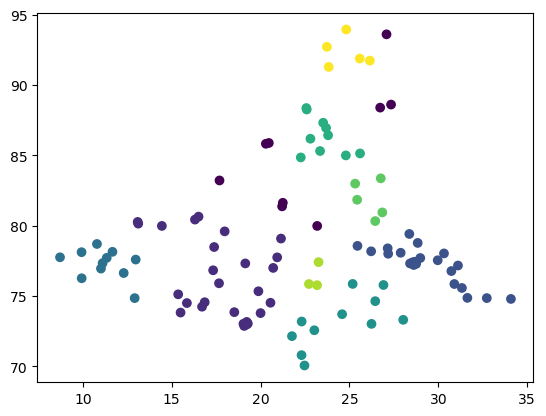

In [8]:
import matplotlib.pyplot as plt

plt.scatter(unique_cities.iloc[:,1],unique_cities.iloc[:,2],c=labels)
plt.show()

In [9]:
unique_cities_1=w[["city","weather","temperature_c"]].drop_duplicates()
unique_cities_1



,city,weather,temperature_c
0,Mumbai,1,29.0
1,Mumbai,1,28.0
2,Mumbai,1,27.0
4,Mumbai,0,28.0
5,Mumbai,20,32.0
...,...,...,...
6574,Panaji,12,33.0
6582,Panaji,16,33.0
6587,Panaji,5,23.0
6588,Panaji,0,28.0


In [10]:
from sklearn.cluster import DBSCAN

coords_1=unique_cities_1[["weather","temperature_c"]].values

dbs=DBSCAN(eps=2,min_samples=3)
labels_1=db.fit_predict(coords_1)

unique_cities_1["cluster"]=labels_1

unique_cities_1

,city,weather,temperature_c,cluster
0,Mumbai,1,29.0,0
1,Mumbai,1,28.0,0
2,Mumbai,1,27.0,0
4,Mumbai,0,28.0,0
5,Mumbai,20,32.0,1
...,...,...,...,...
6574,Panaji,12,33.0,1
6582,Panaji,16,33.0,1
6587,Panaji,5,23.0,0
6588,Panaji,0,28.0,0


In [11]:
print(unique_cities_1["cluster"].value_counts())

cluster
 0    2703
 1    2089
 3       9
 2       4
-1       4
Name: count, dtype: int64


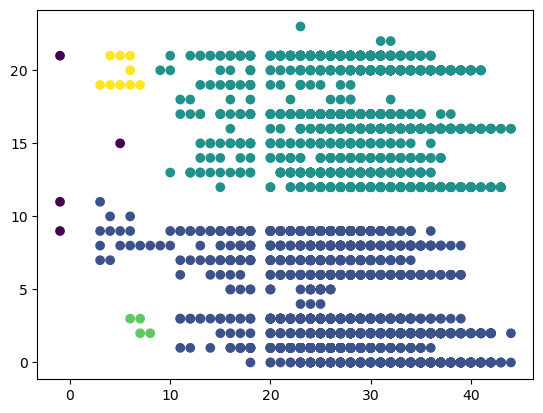

In [13]:
import matplotlib.pyplot as plt

plt.scatter(unique_cities_1.iloc[:,2],unique_cities_1.iloc[:,1],c=labels_1)
plt.show()